# <b>Tarea S11.01. Visualización de Datos con Python y Power BI</b>

## <b>Descripción</b>
Esta práctica integra el uso de Python con las librerías Pandas, Matplotlib, Seaborn o Plotly, así como su integración con Power BI. Trabajarás todo el proceso desde la conexión a MySQL, la creación de visualizaciones avanzadas en Python y finalmente la incorporación de estas visualizaciones a un informe dinámico en Power BI.


### <b>Nivel 1</b>

Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime
from dateutil.relativedelta import relativedelta
import mysql.connector
from mysql.connector import Error

In [3]:
try:
    connection = mysql.connector.connect(host='localhost',
                                         database='ecommerce',
                                         user='root',
                                         password='12345')
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("select database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)

except Error as e:
    print("Error while connecting to MySQL", e)

Connected to MySQL Server version  8.0.42
You're connected to database:  ('ecommerce',)


C:\Users\ramir\AppData\Local\Temp\ipykernel_18636\630580235.py:7: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_Info = connection.get_server_info()


1. <b>Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.</b>

In [4]:
df_transactions = pd.read_sql("SELECT * FROM transactions", connection)
df_users = pd.read_sql("SELECT * FROM users", connection)
df_products = pd.read_sql("SELECT * FROM products", connection)
df_transactions_products = pd.read_sql("SELECT * FROM transactions_products", connection)
df_companies = pd.read_sql("SELECT * FROM companies", connection)
df_credit_card = pd.read_sql("SELECT * FROM credit_card", connection)
df_credit_card_status = pd.read_sql("SELECT * FROM credit_card_status", connection)


C:\Users\ramir\AppData\Local\Temp\ipykernel_18636\1873848848.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions = pd.read_sql("SELECT * FROM transactions", connection)
C:\Users\ramir\AppData\Local\Temp\ipykernel_18636\1873848848.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql("SELECT * FROM users", connection)
C:\Users\ramir\AppData\Local\Temp\ipykernel_18636\1873848848.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql("SELECT * FROM products", connecti

2. <b>Para cada elemento, crea una vista adecuada según las variables especificadas. Interpreta los resultados según sus datos.</b>

<b>Recuerda</b>: cuando selecciones las columnas, piensa siempre en el método que vas a utilizar e incluye las necesarias para la función de visualización que quieras utilizar .

* Una variable numérica.
* Dos variables numéricas.
* Una variable categórica.
* Una variable categórica y una numérica.
* Dos variables categóricas.
* Tres variables combinadas.
* Crea un Pairplot.

#### <b>Una variable numérica. (amount)</b>

<b>Análisis Descriptivo de la Variable 'Amount' (Monto de Transacción)</b>
El siguiente análisis describe las propiedades estadísticas fundamentales de los montos de transacción para una muestra de 100.000 registros.

* <b>Observaciones Clave:</b>
    * <b>Tamaño Muestral y Medidas de Centralidad: El conjunto de datos consta de 100.000 transacciones. El monto medio por transacción es 259.02, mientras que la mediana es 244.24, indicando que el valor típico de una transacción se sitúa ligeramente por debajo de la media.
    * <b>Variabilidad y Rango: La desviación estándar (148.54) refleja una alta variabilidad en los montos. Los valores extremos oscilan entre un mínimo de 2.12 y un máximo de 876.66.
    * <b>Distribución y Asimetría: El análisis de los cuartiles muestra que el 50% central de las transacciones se concentra aproximadamente entre 148.91 y 361.47. La diferencia entre media y mediana, junto con los valores máximos elevados, indica una asimetría positiva (sesgo a la derecha).

* <b>Conclusiones de la Distribución:
El histograma confirma un sesgo a la derecha, con un pico principal entre 150 y 200. Las transacciones grandes, aunque poco frecuentes, influyen significativamente en la media.
En consecuencia, la mediana resulta una medida más representativa del comportamiento típico del gasto que la media.



In [78]:
df_view1 = df_transactions[["amount"]]
df_view1.reset_index(drop=True, inplace=True)
df_view1['id'] = df_view1.index
df_view1

C:\Users\ramir\AppData\Local\Temp\ipykernel_18636\1807039272.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_view1['id'] = df_view1.index


,amount,id
0,395.43,0
1,155.63,1
2,326.01,2
3,161.60,3
4,148.91,4
...,...,...
99995,247.39,99995
99996,349.13,99996
99997,234.22,99997
99998,148.91,99998


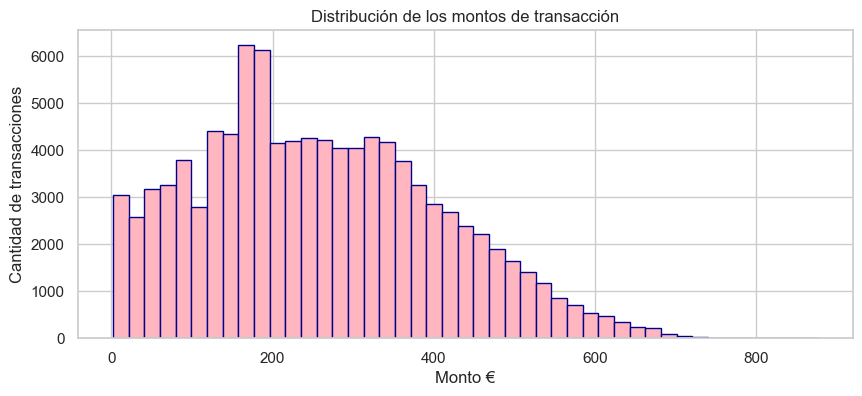

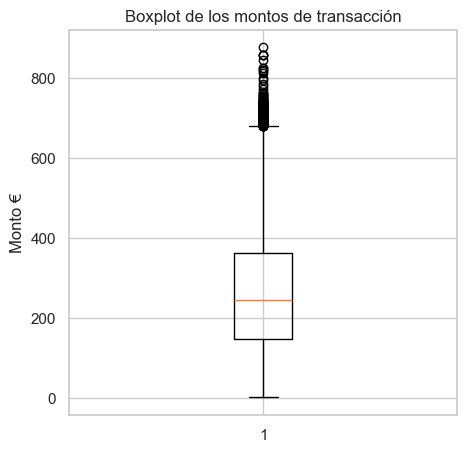

count    100000.00
mean        259.02
std         148.54
min           2.12
25%         148.91
50%         244.24
75%         361.47
max         876.66
Name: amount, dtype: float64

In [79]:
plt.figure(figsize=(10,4))
plt.hist(df_view1["amount"], bins=45, color="lightpink", edgecolor="darkblue")
plt.title("Distribución de los montos de transacción")
plt.xlabel("Monto €")
plt.ylabel("Cantidad de transacciones")

plt.figure(figsize=(5,5))
plt.boxplot(df_view1["amount"])
plt.title("Boxplot de los montos de transacción")
plt.ylabel("Monto €")

plt.show()

df_view1["amount"].describe().round(2)

#### <b>Dos variables numéricas. (amount, year)</b>

<b>Análisis de Tendencia Anual del Monto Total de Transacciones (2015-2024)</b>
El siguiente análisis evalúa la evolución del monto total de transacciones (en millones de euros) a lo largo de un periodo de diez años.

* <b>Descripción General:</b>
    * <b>Periodo analizado:</b> 2015 a 2024 (10 años).
    * <b>Métrica:</b> Monto total de transacciones (en millones de euros).
    * <b>Rango de valores:</b> Los montos oscilan entre aproximadamente 2.545 millones de euros y 2.649 millones de euros.

* <b>Observaciones Clave y Tendencias:</b>
    * <b>Crecimiento Constante Inicial (2015-2017):</b> El monto crece de 2.545.190M € en 2015 a 2.571.455M € en 2017.
    * <b>Caída Notable (2017-2018):</b> Se observa una caída significativa en 2018, bajando a 2.546.897M €, casi volviendo a los niveles de 2015.
    * <b>Recuperación y Pico (2018-2021):</b> El crecimiento se retoma con fuerza, superando los niveles anteriores y alcanzando el máximo histórico de la serie en 2021 con 2.649.463M €.
    * <b>Descenso Post-Pico (2021-2023):</b> Después del pico, el monto desciende durante dos años consecutivos, hasta 2.580.525M € en 2023.
    * <b>Crecimiento Reciente (2023-2024):</b> El año más reciente (2024) muestra una recuperación, cerrando el periodo en 2.593.316M €.

* <b>Pico y Valle:</b>
    * El año con mayor monto de transacciones fue 2021 (2.649.463M €).
    * El año con menor monto de transacciones fue 2015 (2.545.190M €).

En conclusión, la serie temporal muestra una volatilidad moderada con un pico de rendimiento en 2021, seguido de una corrección y una recuperación incipiente en 2024.


In [ ]:
df_transactions['timestamp'].info()
df_transactions["year"] = df_transactions["timestamp"].dt.year

In [76]:
df_view2 = (df_transactions.groupby("year")["amount"].sum().reset_index(name="total_amount"))
df_view2.reset_index(drop=True, inplace=True)
df_view2['id'] = df_view2.index
df_view2

,year,total_amount,id
0,2015,2545190.07,0
1,2016,2556344.72,1
2,2017,2571455.22,2
3,2018,2546896.83,3
4,2019,2610818.43,4
5,2020,2607486.59,5
6,2021,2649462.92,6
7,2022,2640035.64,7
8,2023,2580524.58,8
9,2024,2593316.17,9


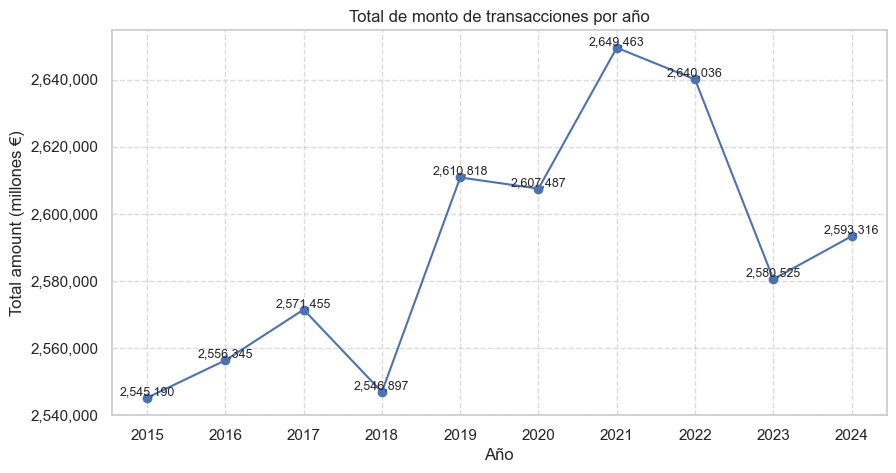

In [77]:
plt.figure(figsize=(10,5))
plt.plot(df_view2["year"], df_view2["total_amount"], marker='o')
plt.title("Total de monto de transacciones por año")
plt.xlabel("Año")
plt.ylabel("Total amount (millones €)")
plt.xticks(years := df_view2["year"].unique())
plt.grid(True, linestyle='--', alpha=0.7)
for x, y in zip(df_view2["year"], df_view2["total_amount"]):
    plt.text(x, y, f'{y:,.0f}', 
             ha='center', 
             va='bottom', 
             fontsize=9,
             fontweight='light')
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.show()


#### <b>Una variable categórica. (company [country])</b>

<b>Análisis del Número de Compañías por País</b>
El gráfico evidencia una distribución desigual de compañías entre países. 

* <b>Observaciones Clave:</b>
    * <b>Concentración de Mercados Maduros:</b> Existe una mayor concentración de empresas en Suecia y Países Bajos, seguidos por Estados Unidos, Reino Unido e Italia, indicando que estos son mercados estratégicos, maduros y altamente atractivos para el negocio.
    * <b>Mercados Emergentes/Barreras de Entrada:</b> En contraste, países como España, China y Francia presentan una baja presencia empresarial, lo que puede reflejar barreras de entrada, menor prioridad estratégica o mercados aún poco explotados.

* <b>Implicaciones Estratégicas:</b>
    * <b>Estrategia de Expansión y Priorización:</b> El número de compañías por país es un indicador de prioridad estratégica. Los países con alta presencia requieren optimización y consolidación, mientras que los de baja presencia representan oportunidades de expansión y diversificación.
    * <b>Gestión del Riesgo:</b> Una alta concentración en pocos países implica un riesgo de dependencia geográfica (regulación, crisis económicas). Diversificar hacia países con menor presencia ayuda a reducir riesgos y aumentar la resiliencia del negocio.

En conjunto, el análisis permite transformar una visión descriptiva en una herramienta estratégica para la toma de decisiones empresariales.








In [ ]:
df_view3 = df_companies['country'].value_counts().reset_index(name="total_companies")
df_view3.reset_index(drop=True, inplace=True)
df_view3['id'] = df_view3.index
df_view3

,country,total_companies,id
0,Sweden,11,0
1,Netherlands,10,1
2,United States,9,2
3,United Kingdom,9,3
4,Italy,9,4
5,Germany,8,5
6,Belgium,8,6
7,Norway,7,7
8,Australia,6,8
9,New Zealand,6,9


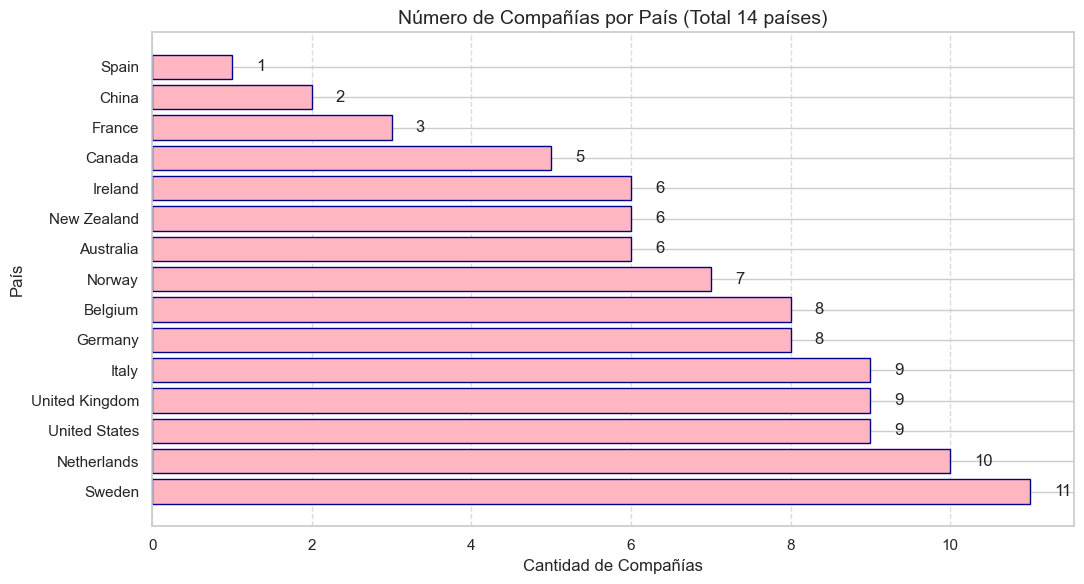

In [ ]:
plt.figure(figsize=(11, 6))
bars = plt.barh(df_view3['country'], df_view3['total_companies'], color='lightpink', edgecolor='darkblue')
plt.title('Número de Compañías por País (Total 14 países)', fontsize=14)
plt.xlabel('Cantidad de Compañías')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
for bar in bars:
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}', va='center')
plt.tight_layout()
plt.show()

#mirarse sns.countplot


##### <b>Una variable categórica y una numérica. (country & amount%)</b>
<b>Análisis de Cuota de Mercado por País (Amount %)</b>
El siguiente análisis describe las variaciones porcentuales en la cuota de mercado por país entre 2021 y 2023, proporcionando una visión de la dinámica competitiva relativa de cada región.

* <b>Observaciones Clave:
    * <b>Aumento de "Otros":</b> La categoría "Otros" ha crecido un 1.5%, lo que sugiere que los mercados con menor volumen están ganando un peso marginalmente mayor en la distribución total, o que los mercados principales están perdiendo tracción.
    * <b>Caída Notoria de Germany:</b> Alemania es el país que presenta la mayor caída porcentual en su cuota de mercado, perdiendo 2.8 puntos porcentuales de participación en solo dos años.
    * <b>Ganancias Moderadas de Sweden y France:</b> Suecia y Francia son los únicos mercados principales que muestran un ligero crecimiento en su cuota relativa.
    * <b>Estabilidad General:</b> Países como Italia, Reino Unido y Países Bajos mantienen su cuota de mercado relativamente estable, con variaciones menores a un punto porcentual.

En conclusión, el análisis de cuota de mercado revela una reconfiguración modesta del panorama competitivo, con Alemania como el principal perdedor relativo de participación, y Suecia y Francia como los únicos mercados principales que logran expandir su peso.



In [81]:
df_view4 = pd.merge(df_transactions, df_companies[['id', 'country']], left_on='company_id', right_on='id')

df_view4

,id_x,card_id,company_id,timestamp,amount,declined,user_id,lat,longitude,product_ids,year,id_y,country
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,4713,46.199929,1.4355402821327607,"16,26,97,87",2024,b-2458,Netherlands
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,438,41.597206,12.22175994259365,"66,69,87",2016,b-2370,Sweden
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,2118,29.757296,-95.37963676492454,"30,11,16,81",2020,b-2390,Ireland
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,2115,53.548884,-113.50305274646564,72,2017,b-2230,United States
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,3025,52.208370,5.690806474241335,18,2017,b-2266,Sweden
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,247.39,0,429,52.522274,13.404944885498775,"20,42,54,46",2022,b-2234,Germany
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,349.13,0,3074,39.027118,-8.105230306688146,"30,87,5,66",2024,b-2522,United Kingdom
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,234.22,0,1008,59.332666,18.07532343085639,"16,49",2019,b-2302,Germany
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,148.91,0,680,52.063504,4.308615909614539,18,2023,b-2250,Italy


In [61]:
def get_top6_data(df, year_value):
    
    df_year = df[df['year'] == year_value] 
    share = df_year.groupby('country')['amount'].sum().sort_values(ascending=False)
    top_6 = share.head(6)
    others = pd.Series({'Otros': share.iloc[6:].sum()})
    
    return pd.concat([top_6, others])


view4_2021 = get_top6_data(df_view4, 2021)
view4_2023 = get_top6_data(df_view4, 2023)

print(view4_2021) 
print(view4_2023)

Sweden            425971.05
Germany           412694.02
Netherlands       374157.78
United Kingdom    355225.23
Italy             354119.52
France            120136.99
Otros             607158.33
dtype: float64
Sweden            422308.43
Netherlands       370644.07
United Kingdom    358159.20
Italy             343685.93
Germany           331281.08
France            123799.87
Otros             630646.00
dtype: float64


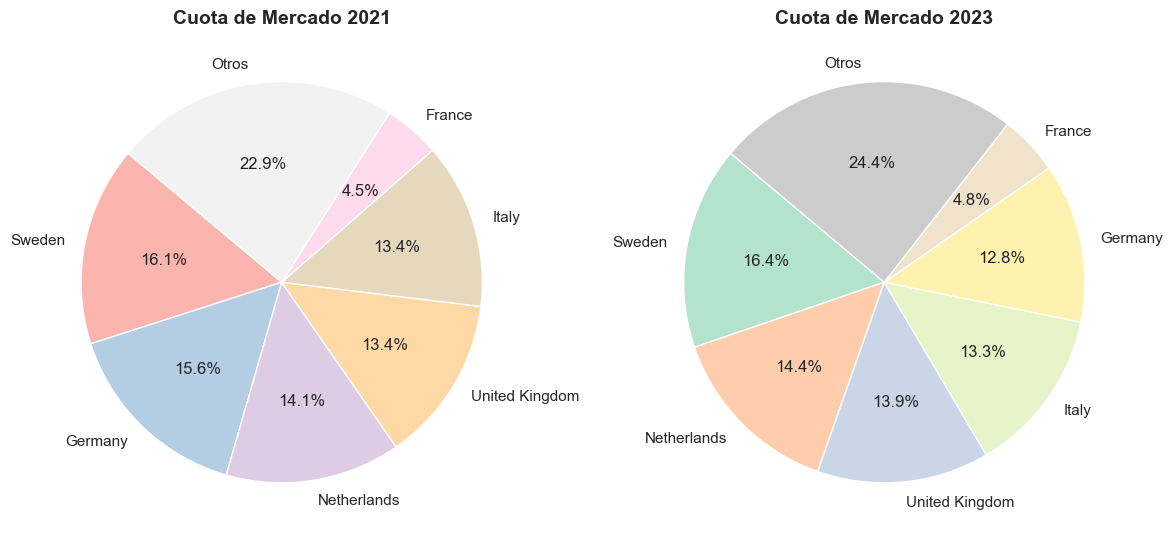

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

view4_2021.plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=140, cmap='Pastel1')
ax1.set_title('Cuota de Mercado 2021', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

view4_2023.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=140, cmap='Pastel2')
ax2.set_title('Cuota de Mercado 2023', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

In [83]:

df_view4 = pd.concat([view4_2021, view4_2023], axis=1, keys=['Cuota 2021 (%)', 'Cuota 2023 (%)'])

df_view4['Variación (%)'] = df_view4['Cuota 2023 (%)'] - df_view4['Cuota 2021 (%)']

def get_table_from_sums(data_2021_sums, data_2023_sums):
    df_combined = pd.concat([data_2021_sums, data_2023_sums], axis=1, keys=['Cuota 2021 (%)', 'Cuota 2023 (%)'])
    
    df_combined['Cuota 2021 (%)'] = (df_combined['Cuota 2021 (%)'] / df_combined['Cuota 2021 (%)'].sum()) * 100
    df_combined['Cuota 2023 (%)'] = (df_combined['Cuota 2023 (%)'] / df_combined['Cuota 2023 (%)'].sum()) * 100
    df_combined['Variación (%)'] = df_combined['Cuota 2023 (%)'] - df_combined['Cuota 2021 (%)']

    df_total = pd.DataFrame(df_combined.sum(), columns=['Total']).T
    df_final = pd.concat([df_combined, df_total])

    return df_final.round(2)

df_table_view4 = get_table_from_sums(view4_2021, view4_2023)

df_table_view4

,Cuota 2021 (%),Cuota 2023 (%),Variación (%)
Sweden,16.08,16.37,0.29
Germany,15.58,12.84,-2.74
Netherlands,14.12,14.36,0.24
United Kingdom,13.41,13.88,0.47
Italy,13.37,13.32,-0.05
France,4.53,4.80,0.26
Otros,22.92,24.44,1.52
Total,100.00,100.00,-0.00


#### <b>Dos variables categóricas. (Product & Country)</b>
<b>Análisis Comparativo: Unidades Vendidas (2021 vs 2023)</b>
El siguiente análisis evalúa el desempeño de los tres productos más vendidos en seis mercados europeos clave y un grupo "Otros", utilizando un gráfico de barras agrupadas para comparar los años 2021 y 2023.
* <b>Observaciones Clave:</b>
    * <b>Consistencia de Productos:</b> Existe una alta consistencia en los productos que conforman el top 3 (dooku solo, Winterfell, the duel) en la mayoría de los países.

    * <b>Tendencia General de Contracción:</b> La mayoría de los mercados principales muestran una disminución o estancamiento en las ventas de 2023 (naranja) en comparación con 2021 (azul claro).

    * <b>Alemania, Producto Distinto y Caída Significativa: </b> El mercado alemán es el único con una preferencia local única (karstark warden). Este mercado experimenta una notable reducción en las ventas de sus productos principales en 2023, lo que visualiza una contracción sustancial de la participación de mercado interanual.

    * <b>Estabilidad en Países Bajos y "Otros":</b> Países Bajos presenta una notable estabilidad, manteniendo volúmenes de venta consistentes entre ambos periodos analizados, operando como un mercado resiliente.

    * <b>Reino Unido, Mayor Crecimiento de un Producto: </b> Se identifica un crecimiento puntual en el Reino Unido, donde el producto Winterfell muestra una trayectoria ascendente significativa en 2023, pasando de ser el menos vendido a ser el líder en ese mercado específico.


En conclusión, los datos gráficos sugieren un entorno de mercado desafiante en 2023 para la mayoría de las regiones, con un rendimiento inferior al de 2021, a excepción de casos puntuales de estabilidad o crecimiento específicos de productos.


In [ ]:
df_view5 = pd.merge(df_transactions, df_transactions_products, left_on='id', right_on='transaction_id')
df_view5 = pd.merge(df_view5, df_products, left_on='product_id', right_on='id', suffixes=('', '_prod'))
df_view5 = pd.merge(df_view5, df_companies, left_on='company_id', right_on='id', suffixes=('', '_comp'))

df_view5 = df_view5[df_view5['year'].isin([2021, 2023])]

top_6_paises = df_view5['country'].value_counts().nlargest(6).index
df_view5['country_group'] = df_view5['country'].apply(lambda x: x if x in top_6_paises else 'Otros')

def get_top_3(group):
    return group['product_name'].value_counts().nlargest(3).index.tolist()

top_prods_dict = df_view5.groupby('country_group', group_keys=False).apply(get_top_3).to_dict()

df_view5 = pd.concat([df_view5[(df_view5['country_group'] == p) & (df_view5['product_name'].isin(prods))]
    for p, prods in top_prods_dict.items()])

df_view5


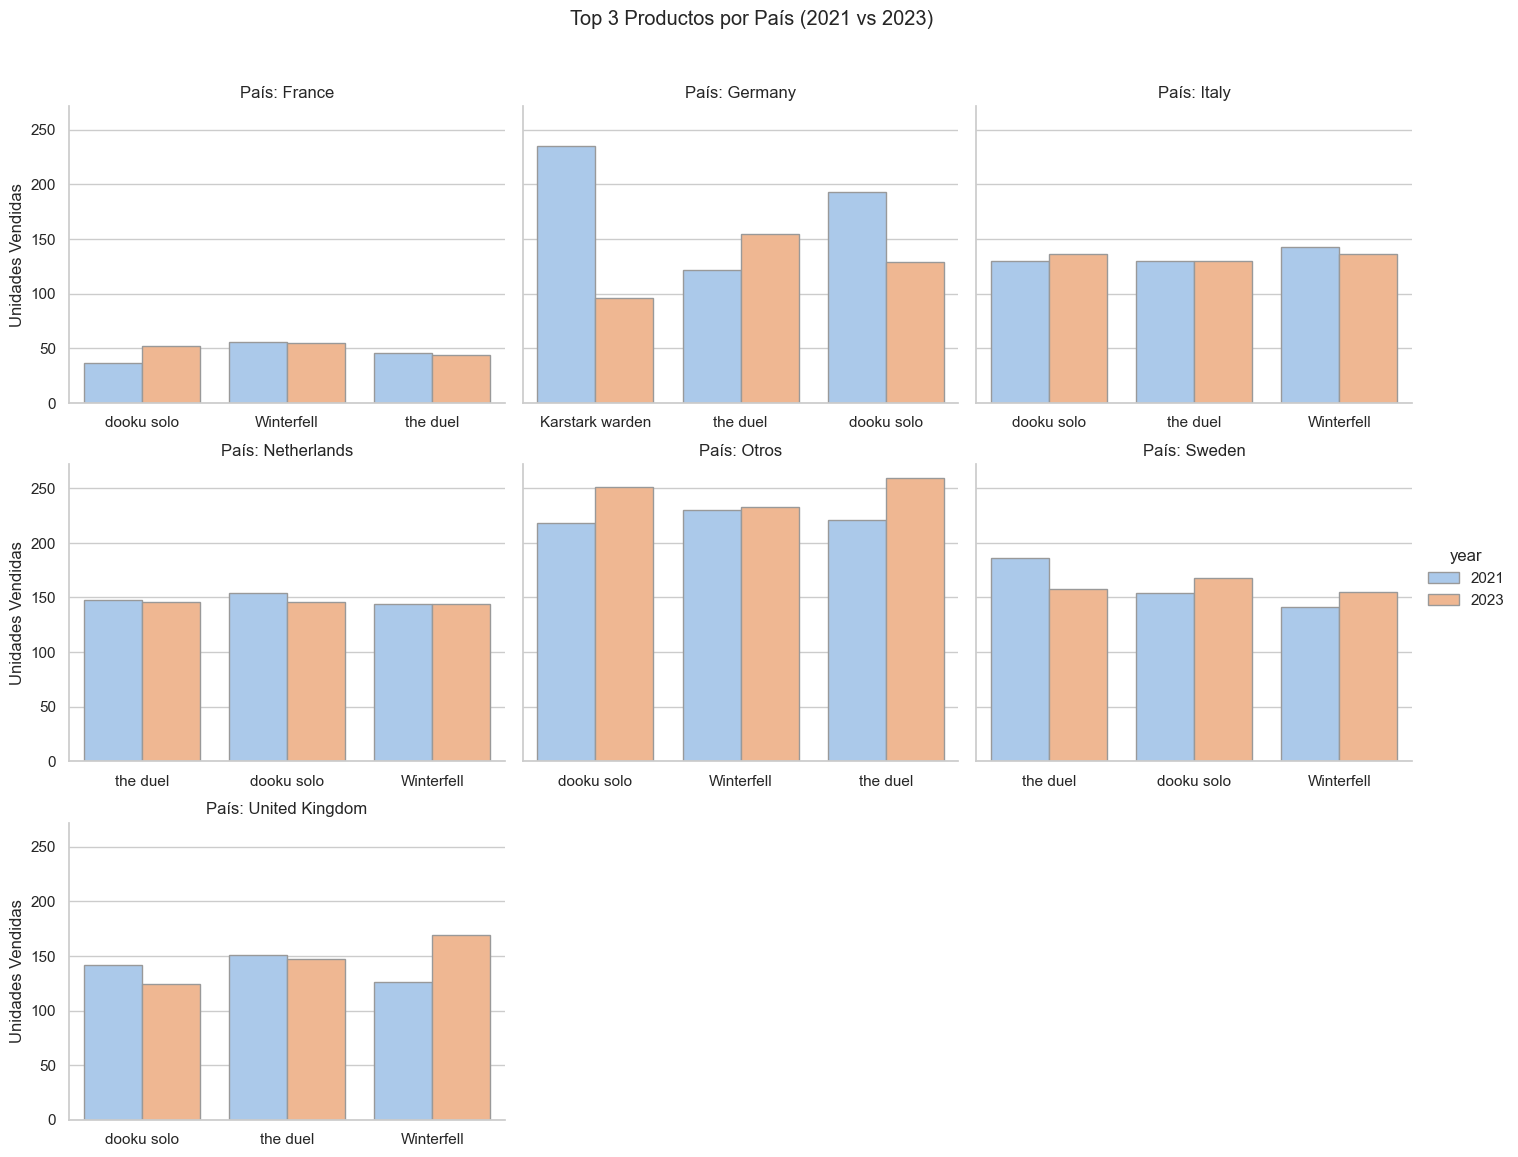

In [ ]:

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_view5, 
    kind="count",
    x='product_name', 
    hue="year", 
    col="country_group", 
    col_wrap=3,
    sharex=False,
    palette="pastel", 
    edgecolor=".6",
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=0)
g.set_titles("País: {col_name}")
g.set_axis_labels("", "Unidades Vendidas")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Top 3 Productos por País (2021 vs 2023)')

plt.show()

#### <b>Tres variables combinadas.(country, amount, year)</b>
<b>Análisis Multianual de Variables Cuantitativas.</b>

* <b>Análisis Comparativo:</b> Participación de Mercado (2021-2023)
El siguiente análisis evalúa el desempeño de los seis países con mayor participación de mercado utilizando un gráfico de barras agrupadas horizontales, comparando los montos totales (Market Share) para los años 2021 (azul claro), 2022 (naranja) y 2023 (verde).

* <b>Observaciones Clave:</b>
    * <b>Suecia, Líder Consolidado:</b> Suecia mantiene consistentemente la mayor participación de mercado en los tres años analizados, superando los 400.000 en monto total cada año y mostrando un ligero crecimiento en 2023.
    * <b>Tendencia General de Contracción en 2023:</b> Cinco de los seis países principales (Alemania, Países Bajos, Reino Unido, Italia y Francia) muestran una disminución notable en su participación de mercado en 2023 (verde) en comparación con los dos años anteriores (2021 y 2022). Esto sugiere un entorno de mercado desafiante o una contracción generalizada para estas regiones.
    * <b>Alemania, Mayor Variabilidad Anual:</b> El mercado alemán presenta la mayor volatilidad interanual. Alcanzó su pico de rendimiento en 2022, pero experimentó la caída más pronunciada en 2023, reduciendo su monto a niveles inferiores a 2021.
    * <b>Estabilidad Relativa del Reino Unido e Italia:</b> El Reino Unido e Italia muestran patrones de comportamiento similares: picos de rendimiento en 2022 seguidos de caídas en 2023, aunque mantienen una participación estable comparada con 2021.
    * <b>Francia, Menor Participación y Caída Constante:</b> Francia es el país con la menor participación dentro del top 6 y presenta una tendencia a la baja desde 2021, con la menor brecha entre sus años, pero sin signos de crecimiento.
    
En conclusión, los datos gráficos sugieren un entorno de mercado desafiante en 2023 para la mayoría de las regiones analizadas, con un rendimiento inferior al de 2021 y 2022, a excepción del mercado sueco que mantiene su liderazgo y estabilidad.

In [85]:
df_view6 = pd.merge(df_transactions, df_companies, left_on='company_id', right_on='id', suffixes=('', '_comp'))

años_analisis = [2021, 2022, 2023]
df_view6 = df_view6[df_view6['year'].isin(años_analisis)].copy()

top_6_paises = df_view6.groupby('country')['amount'].sum().nlargest(6).index

df_view6 = df_view6[df_view6['country'].isin(top_6_paises)]

df_view6 = df_view6.groupby(['country', 'year'], as_index=False)['amount'].sum()

df_view6.reset_index(drop=True, inplace=True)
df_view6['id'] = df_view6.index
df_view6

,country,year,amount,id
0,France,2021,120136.99,0
1,France,2022,126333.25,1
2,France,2023,123799.87,2
3,Germany,2021,412694.02,3
4,Germany,2022,420451.68,4
5,Germany,2023,331281.08,5
6,Italy,2021,354119.52,6
7,Italy,2022,341266.51,7
8,Italy,2023,343685.93,8
9,Netherlands,2021,374157.78,9


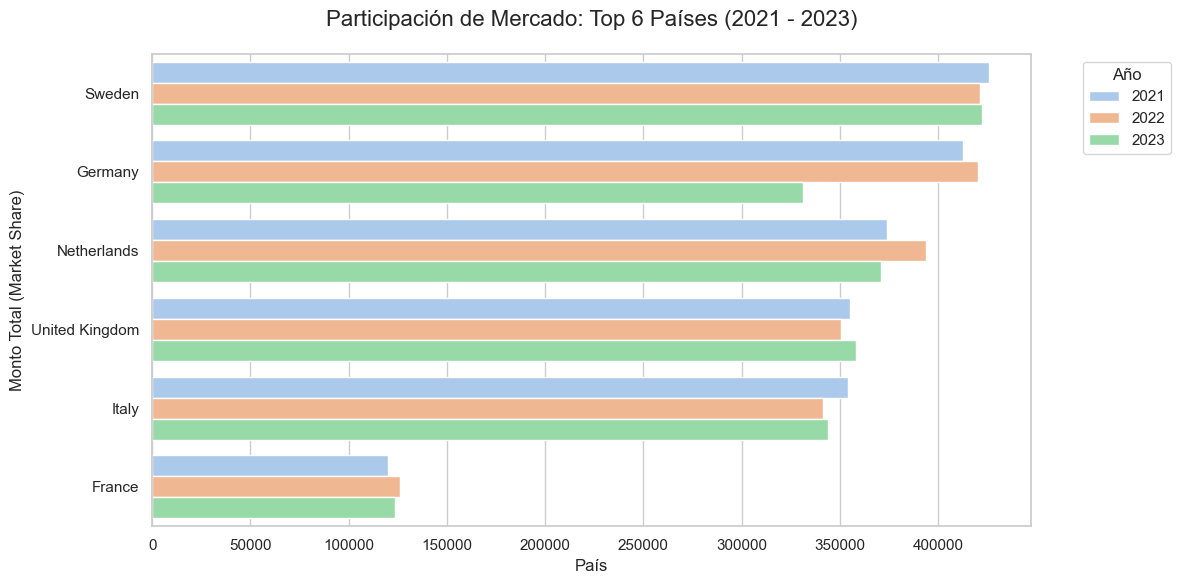

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plot = sns.barplot(
    data=df_view6,
    x='amount',
    y='country',
    hue='year',
    palette='pastel',
    orient='h',
    order=top_6_paises
)

plt.title('Participación de Mercado: Top 6 Países (2021 - 2023)', fontsize=16, pad=20)
plt.xlabel('País', fontsize=12)
plt.ylabel('Monto Total (Market Share)', fontsize=12)
plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### <b>Crea un Pairplot.</b>
##### <b>Cuatro variables combinadas (amount, user_age, num_products, price) y estado de transacción (declined).</b>
<b>Análisis Multivariado de Transacciones de Comercio Electrónico.</b>

<b>Análisis Comparativo: Transacciones Aprobadas (azul) vs. Denegadas (naranja)</b>
El siguiente análisis evalúa las relaciones entre el monto total de la transacción (amount), la edad del usuario (user_age), el número de productos comprados (num_products) y el precio unitario del producto (price), utilizando un pairplot de Seaborn. Se diferencia visualmente entre transacciones aprobadas (azul) y denegadas (naranja, que son una minoría).
<b>Observaciones Clave:</b>

* <b>Distribución y Correlación de Variables:</b>
    * <b>Existe una fuerte correlación positiva entre amount y price, lo cual es esperado:</b> a mayor precio unitario, mayor el monto total de la transacción. La relación es casi lineal, como se observa en el gráfico inferior izquierdo.
    * La variable user_age parece estar uniformemente distribuida entre los 20 y 70 años, sin una concentración notable en ningún rango de edad específico.
    * La mayoría de las transacciones involucran un número bajo de productos (num_products), predominantemente 1 o 2, como muestra el histograma diagonal.
    * <b>Comportamiento de Transacciones Denegadas (Naranja):</b>
    Las transacciones denegadas son una minoría clara en el conjunto de datos visualizado, lo cual es positivo para la salud general del sistema.
    * En las parcelas que involucran user_age (fila 2 y columna 2), los puntos naranjas (denegados) parecen distribuidos aleatoriamente dentro del rango de edad, lo que sugiere que la edad por sí sola no es un predictor principal de rechazo.
    * No se observan conglomerados distintos de puntos naranjas que sugieran un patrón obvio de fraude o error sistémico a simple vista en ninguna de las combinaciones de variables. Los rechazos ocurren en todo el espectro de montos, edades, y precios.

En conclusión, los datos gráficos sugieren un conjunto de datos de transacciones relativamente sano, con una baja tasa de rechazo que no parece estar fuertemente ligada a ninguna de las variables cuantitativas analizadas individualmente. El análisis visual no revela patrones obvios que diferencien claramente las transacciones denegadas de las aprobadas, lo que podría implicar que otros factores (como límites de crédito, errores de entrada, etc.) o combinaciones más complejas son los causantes de los rechazos. 

In [ ]:
hoy = datetime.today()

def calcular_edad(fecha_nacimiento):
    if pd.isna(fecha_nacimiento):
        return None
    return relativedelta(hoy, fecha_nacimiento).years

df_users['user_age'] = df_users['birth_date'].apply(calcular_edad)

df_num_products = (df_transactions_products.groupby('transaction_id').size().reset_index(name='num_products'))

df_price_per_transaction = (df_transactions_products.merge(df_products[['id', 'price']], left_on='product_id', right_on='id'))

df_view7 = (df_transactions
            .merge(df_users[['id', 'user_age']], left_on='user_id', right_on='id')
            .merge(df_num_products, left_on='id_x', right_on='transaction_id')
            .merge(df_price_per_transaction, left_on='id_x', right_on='transaction_id')
)

df_view7 = df_view7[[
    'amount',
    'user_age',
    'num_products',
    'price',
    'declined'
]]
df_view7.reset_index(drop=True, inplace=True)
df_view7['id'] = df_view7.index
df_view7

,amount,user_age,num_products,price,declined,id
0,395.43,29,4,180.91,0,1
1,395.43,29,4,53.01,0,2
2,395.43,29,4,96.26,0,3
3,395.43,29,4,65.25,0,4
4,155.63,68,3,2.12,0,5
...,...,...,...,...,...,...
253386,234.22,68,2,180.91,0,253387
253387,234.22,68,2,53.31,0,253388
253388,148.91,56,1,148.91,0,253389
253389,74.54,59,2,53.01,0,253390


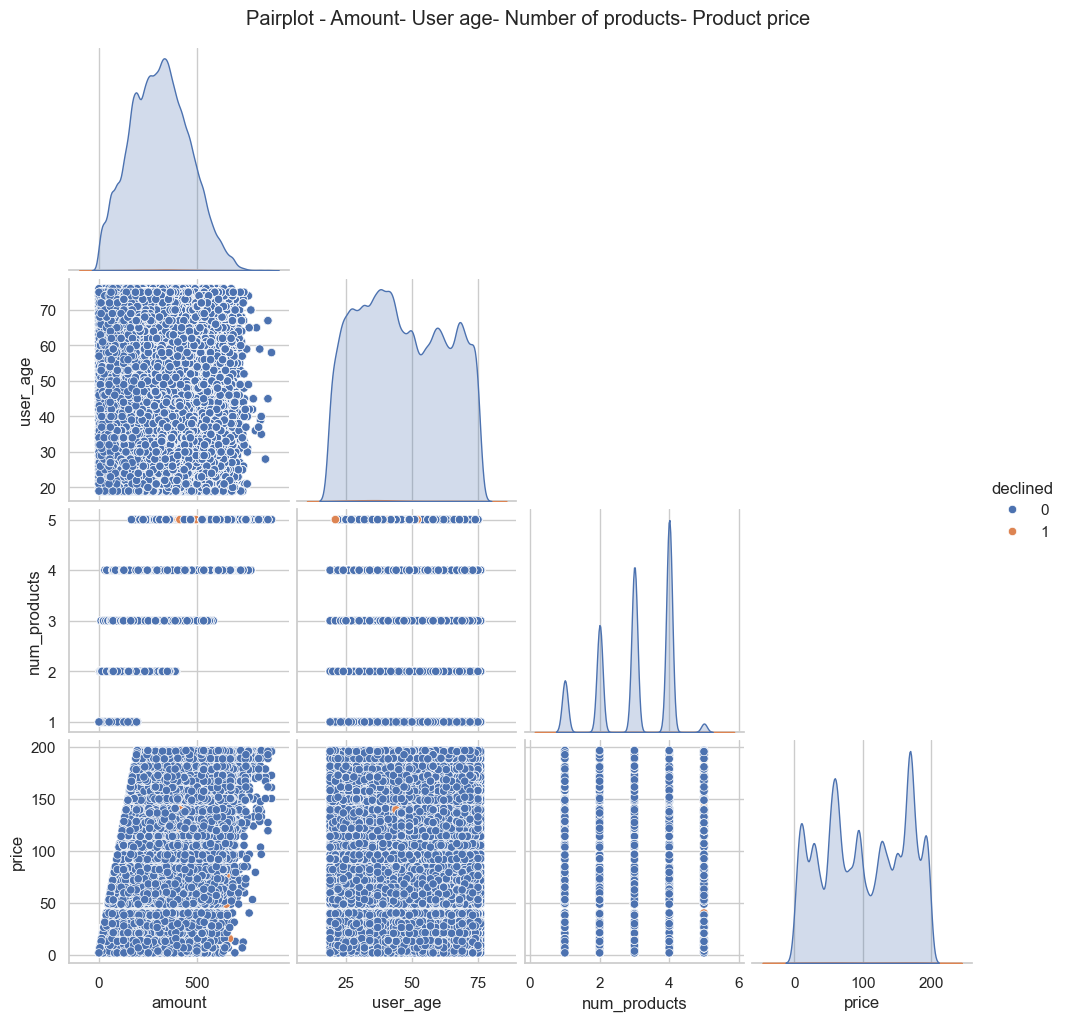

In [ ]:



sns.pairplot(df_view7,hue='declined',diag_kind='kde',corner=True)

plt.suptitle('Pairplot - Amount- User age- Number of products- Product price', y=1.02)

plt.show()


### <b>Nivel 2</b>

1. Representa la correlación de algunas variables e interpreta los resultados según tus datos.


2. Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.


#### <b>Gráfico de Dispersión.</b>
##### <b>Relación entre precio del producto (price) y peso del producto (weight).</b>

<b>Evaluación de la Relación entre el Peso del Producto y su Precio</b>

El presente análisis examina la relación entre el peso del producto (weight) y su precio (price) mediante un gráfico de dispersión con ajuste de regresión lineal. El objetivo es identificar si el peso físico del producto actúa como un factor relevante en la determinación de su precio dentro del conjunto de datos analizado.

<b>Observaciones Clave:</b>

* <b>Relación entre Precio y Peso:</b>

Se observa una tendencia positiva débil entre el peso del producto y su precio, reflejada en la pendiente ascendente de la línea de regresión.
Esto indica que, en promedio, los productos de mayor peso tienden a presentar precios ligeramente superiores, lo cual puede estar asociado a mayores costes de fabricación, materiales o logística.
No obstante, la pendiente es moderada, lo que sugiere que el peso por sí solo no explica de forma significativa la variabilidad del precio.

* <b>Alta Dispersión de los Datos:</b>

Para valores similares de peso se observan precios muy variados, incluyendo productos ligeros con precios elevados y productos pesados con precios bajos.
Esta dispersión indica que existen otros factores determinantes del precio no representados en este gráfico, tales como la marca, el tipo de producto, el valor percibido, el diseño o características funcionales adicionales.

* <b>Ausencia de Agrupamientos Claros:</b>

No se identifican conglomerados bien definidos que sugieran segmentos claros de productos basados únicamente en peso y precio.
El comportamiento continuo de los puntos refuerza la idea de un mercado heterogéneo, con productos diversos que no siguen una regla simple de “a mayor peso, mayor precio”.

En conclusión, el análisis visual sugiere que existe una relación positiva débil entre el peso del producto y su precio, pero esta relación no es lo suficientemente fuerte como para considerar el peso un predictor principal del precio. El elevado nivel de dispersión indica que el precio está influenciado por múltiples variables adicionales que no se capturan en este análisis bivariado. Para una comprensión más completa del comportamiento del precio, sería necesario incorporar otras variables como la categoría del producto, el almacén, el número de unidades vendidas o el contexto de la transacción.

In [ ]:
df_view8 = df_products[['weight', 'price']]

df_view8.reset_index(drop=True, inplace=True)
df_view8['id'] = df_view8.index
df_view8

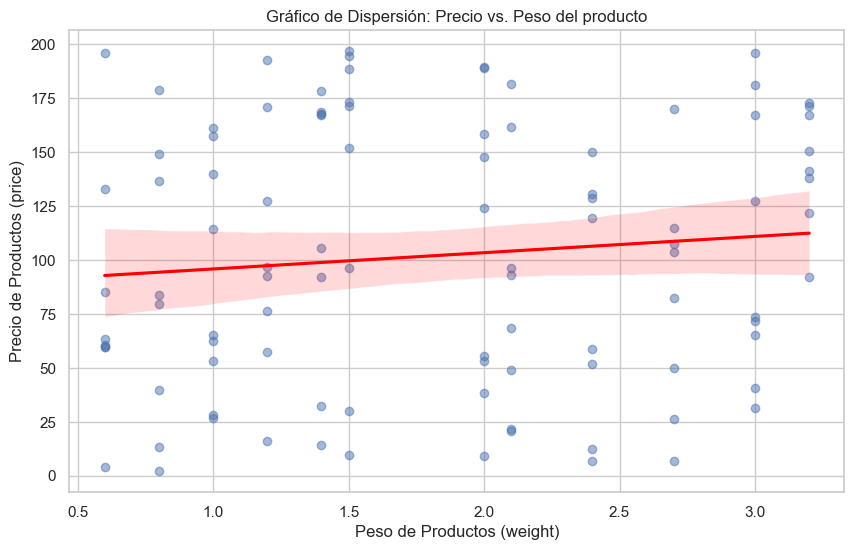

In [47]:
plt.figure(figsize=(10, 6))
sns.regplot(x='weight', y='price', data=df_view8, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersión: Precio vs. Peso del producto')
plt.xlabel('Peso de Productos (weight)')
plt.ylabel('Precio de Productos (price)')
plt.grid(True)
plt.show()

In [ ]:
df_transactions['lat'] = pd.to_numeric(df_transactions['lat'], errors='coerce')
df_view9 = df_transactions.dropna(subset=['lat', 'amount'])

df_view9.reset_index(drop=True, inplace=True)
df_view9['id'] = df_view9.index

df_view9

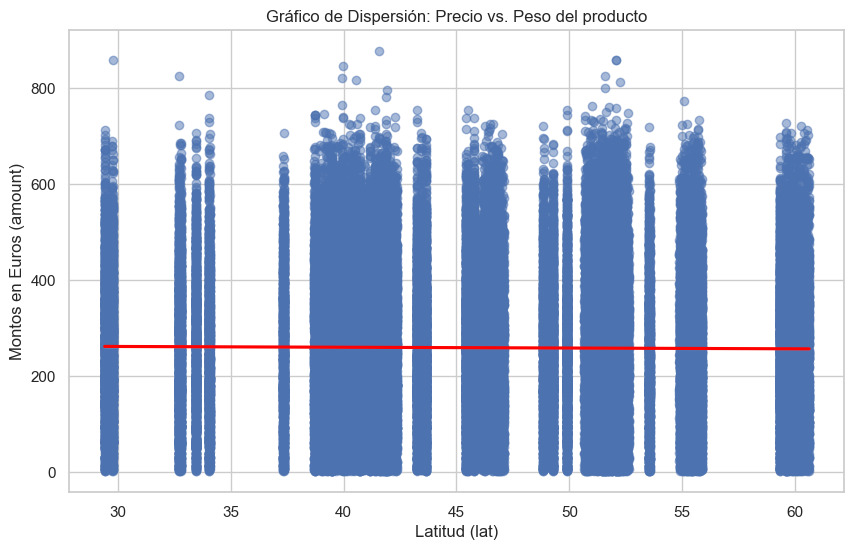

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='lat', y='amount', data=df_view9, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersión: Precio vs. Peso del producto')
plt.xlabel('Latitud (lat)')
plt.ylabel('Montos en Euros (amount)')
plt.grid(True)
plt.show()

#### <b>Dos variables numéricas. (Número de productos y monto de la transacción)</b>

##### <b>Análisis Bivariado: Tamaño del carrito y valor de la transacción</b>

El siguiente análisis examina la relación entre el número de productos incluidos en una transacción (num_products) y el monto total de la misma (amount), utilizando un jointplot. Este tipo de visualización permite observar simultáneamente la relación entre ambas variables y sus distribuciones marginales.

* <b>Observaciones Clave:</b>

    * <b>Relación positiva clara entre variables:</b>
    Se observa una tendencia positiva bien definida entre el número de productos y el monto de la transacción. A medida que aumenta el tamaño del carrito, el valor total de la compra crece de forma consistente, lo cual es coherente con la lógica de comercio electrónico.

    * <b>Estructura discreta del tamaño del carrito:</b>
    La variable num_products presenta valores discretos (principalmente entre 1 y 5 productos), lo que genera bandas verticales claramente diferenciadas en el gráfico. Esto indica que la mayoría de las transacciones se concentran en carritos pequeños o medianos.

    * <b>Incremento progresivo del rango de montos:</b>
    A mayor número de productos, no solo aumenta el valor medio del monto, sino también su variabilidad. Las transacciones con 4 y 5 productos muestran una dispersión considerablemente mayor, lo que sugiere combinaciones más heterogéneas de precios unitarios.

    * <b>Distribuciones marginales informativas:</b>
    Los histogramas marginales refuerzan que los carritos con pocos productos son los más frecuentes, mientras que los montos de transacción presentan una distribución asimétrica, con una mayor concentración en valores bajos y una cola hacia montos elevados.

    * <b>Ajuste lineal consistente:</b>
    La línea de regresión captura adecuadamente la tendencia general de los datos, indicando que el número de productos es un buen predictor del monto total, aunque no el único, dado el nivel de dispersión observado.

En conclusión, el gráfico evidencia una relación directa y estructural entre el tamaño del carrito y el valor de la transacción. Si bien el número de productos explica una parte significativa del comportamiento del monto total, la variabilidad creciente en carritos más grandes sugiere la influencia de factores adicionales, como la combinación de precios unitarios o el tipo de producto adquirido. Este análisis confirma un patrón de compra coherente y consistente con un entorno de comercio electrónico funcional y bien estructurado.

In [ ]:
df_num_products = (df_transactions_products.groupby('transaction_id').size().reset_index(name='num_products'))

df_view10 = (df_transactions.merge(df_num_products,left_on='id',right_on='transaction_id')[['amount', 'num_products']])

df_view10.reset_index(drop=True, inplace=True)
df_view10['id'] = df_view10.index
df_view10

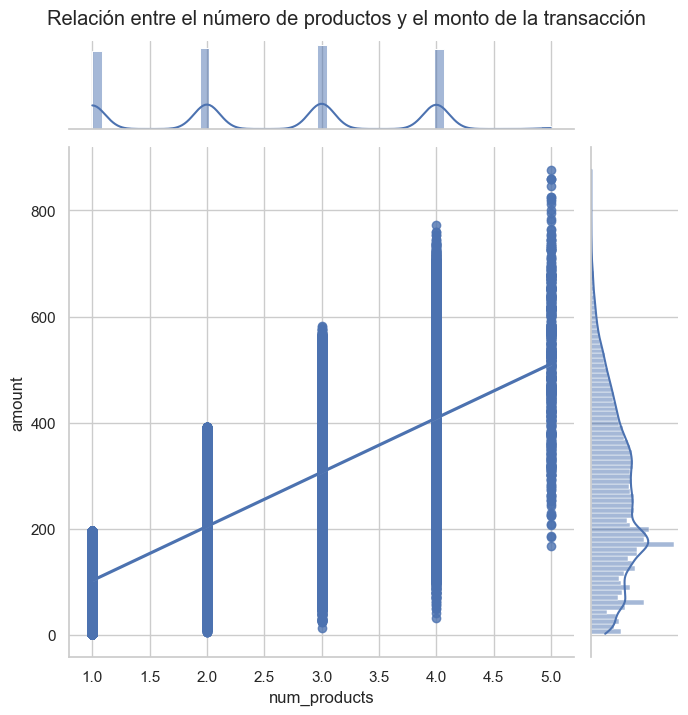

In [50]:
sns.jointplot(data=df_view10, x='num_products', y='amount', kind='reg', height=7, space=0.2)

plt.suptitle('Relación entre el número de productos y el monto de la transacción',y=1.02)

plt.show()


### <b>Nivel 3</b>

1. Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: cuando cargues tus dataframes en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. Por defecto, Power BI elimina duplicados y podrías perder información .


In [21]:
if connection.is_connected():
        cursor.close()
        connection.close()
        print("MySQL connection is closed")

MySQL connection is closed
